# Grundlagen der Transkription an einem Beispiel
## Begriffe
- Pitch: Die Note oder Frequenz eines Tons. Bei der Note wird die Oktave mit angegeben. Z.B. "C3"
- Chroma: Die Klangfarbe. Wie Pitch, nur ohne die Oktave. Z.B. "C"
- FFT: Fast Fourier Transform. Die Funktion, mit der ein Signal in sein Frequenzspektrum umgewandelt wird. Sie ist nötig, um den Pitch zu ermitteln. 
- STFT: Short Time Fourier Transform. Da die Frequenzen in einem Musikstück ständig wechseln, wird es in kurze Abschnitte unterteilt und auf jeden Abschnitt eine FFT angewandt. 

> Im Folgenden wurden die geschriebenen Codeblöcke mit KI-generierten Erklärungen versehen, um die Lesbarkeit und Leserführung zu verbessern.


In [16]:
import librosa
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import Audio

## 1. Vorbereitung: Bibliotheken importieren

Wir verwenden folgende Bibliotheken:
- **librosa**: Hauptbibliothek für Audio- und Musikanalyse
- **numpy**: Numerische Berechnungen und Array-Operationen
- **matplotlib**: Visualisierung von Spectrogrammen und Waveforms
- **music21**: Arbeiten mit Musiknotation und MIDI-Dateien

Laden einer Audio Datei. 
librosa bietet viele nützliche Funktionen und kann beispielsweise den harmonischen vom inharmonischen Teil separieren. 

In [17]:
# load a music file
audio_path = "audio/Tourdion_synth_recorder_violins_metronome_1125.wav"
duration = 3
wav, sr = librosa.load(audio_path, offset=0, duration=duration) # sampling rate is the default 22050 here
longwav, _ = librosa.load(audio_path, offset=25, duration=12)
# wav, sr = librosa.load("tg_bg_audio.wav", offset=24, duration=duration)

# do hpss Harmonic percussive source separation
harmonic, percussive = librosa.effects.hpss(wav) # optional: give margins: margin=(1.0,5.0)
# long_harmonic, long_percussive = librosa.effects.hpss(longwav)

In [18]:
print("Original:")
display(Audio(data=wav, rate=sr))
print("Harmonics:")
display(Audio(data=harmonic, rate=sr))
print("Percussion:")
display(Audio(data=percussive, rate=sr))
# print("Trumpet Example")
# trump, _ = librosa.load(librosa.ex('trumpet'))
# display(Audio(data=trump, rate=_))

Original:


Harmonics:


Percussion:


## 2. Signalverarbeitung: Harmonisch-Perkussive Separation (HPSS)

Ein wichtiger Schritt in der Musikanalyse ist die **Separation von Musikkomponenten**. Musiksignale bestehen aus:
- **Harmonischen Komponenten**: Melodie, Akkorde (Instrumente mit definierten Tonhöhen)
- **Perkussiven Komponenten**: Rhythmus, Drums (kurze, impulsmäßige Signale)

Die HPSS-Methode trennt diese Komponenten automatisch:
- Die harmonischen Komponenten sind wichtig für **Pitch-Erkennung** und **Transkription**
- Die perkussiven Komponenten sind wertvoll für **Beat- und Tempo-Analyse**

In den folgenden Zellen hören Sie die ursprüngliche Audiodatei und die separierten Komponenten.

Die Separierung mit librosa ist noch nicht perfekt. Es sind noch Teile des Harmonischen bei der Perkussion hörbar. 

Die Separierung kann auch sichtbar gemacht werden: 

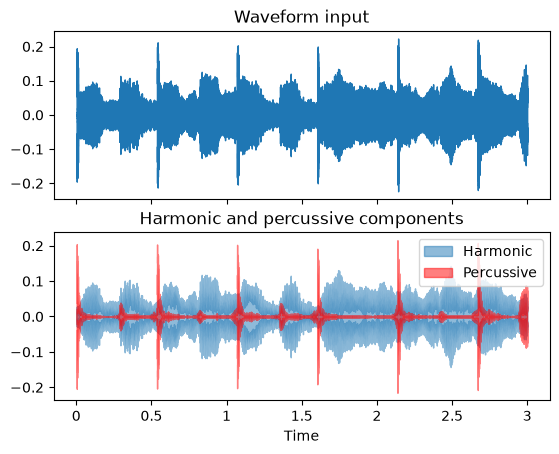

In [21]:
# demonstartion on how to plot stuff
# create plot
fig, ax = plt.subplots(nrows=2, sharex=True)
# plot wav
librosa.display.waveshow(wav, sr=sr, ax=ax[0])
ax[0].set(title="Waveform input")
ax[0].label_outer()
# plot harmonic and percussive components overlayed
librosa.display.waveshow(harmonic, sr=sr, alpha=0.5, ax=ax[1], label='Harmonic')
librosa.display.waveshow(percussive, sr=sr, color='r', alpha=0.5, ax=ax[1], label='Percussive')
ax[1].set(title='Harmonic and percussive components')
ax[1].legend()

## 3. Frequenzanalyse: Spectrogramme und Features

### Spectrogramme - Frequenzinhalt über die Zeit

Ein **Spektrogram** visualisiert, welche Frequenzen zu welchem Zeitpunkt in der Audiodatei vorkommen:
- **Y-Achse**: Frequenz (logarithmisch dargestellt für bessere Wahrnehmung)
- **X-Achse**: Zeit
- **Farbintensität**: Lautstärke/Energie bei dieser Frequenz und Zeit

### Chroma-Features - Tonhöhenklassen

Das **Chroma-Spektrogram** abstrahiert die Frequenzen weiter:
- Es ordnet alle Frequenzen ihren **Tonhöhenklassen** (C, C#, D, ..., B) zu
- Unabhängig von der Oktave (C3, C4, C5 werden alle zu "C")
- Ideal für die Erkennung von **Akkorden** und **Melodien**

Die folgenden Visualisierungen zeigen beide Features nebeneinander.

(1025, 130)


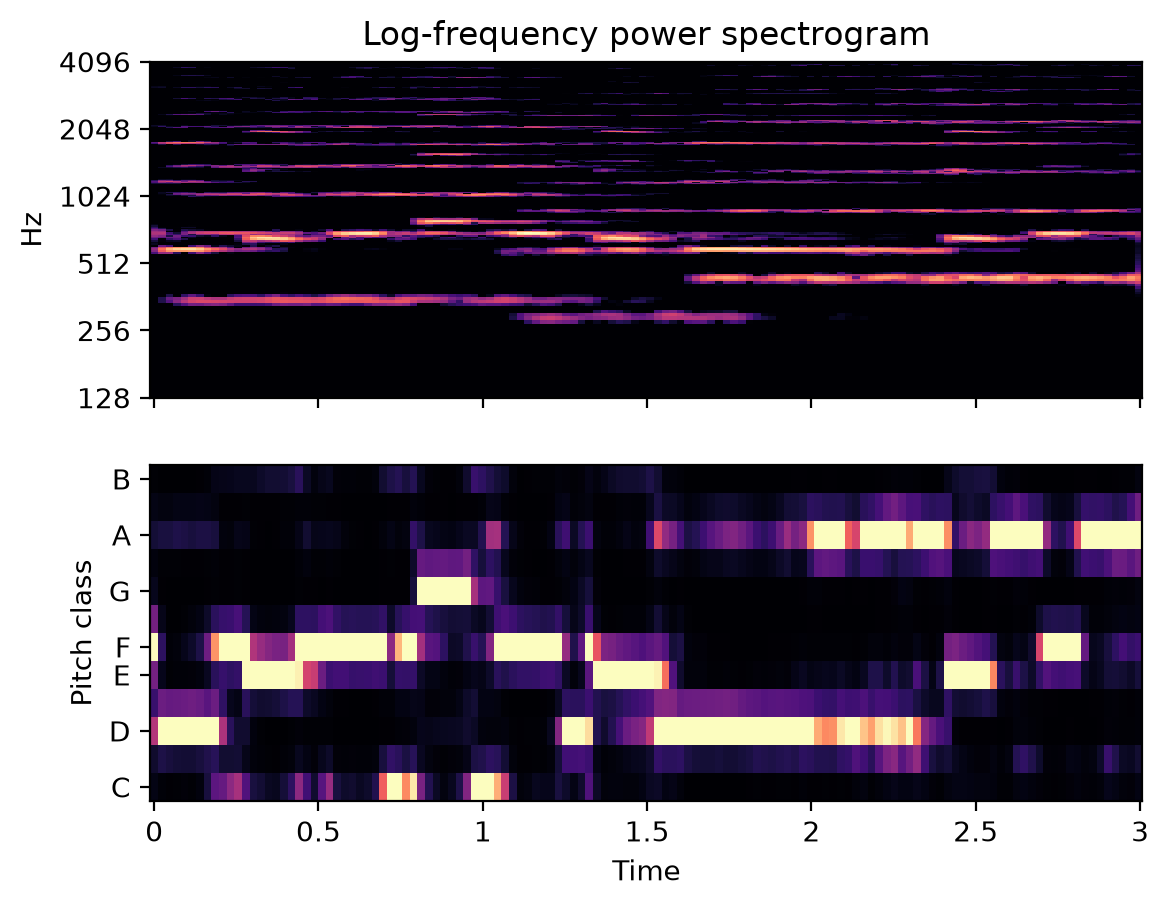

In [47]:
# create plot
fig, ax = plt.subplots(nrows=2, sharex=True)

### Spectrogram
hop_length = 512 # n_fft = 2048, win_length = n_fft, hop_length = win_lenght // 4 = 512
# perform stft ShortTime Fourier Transform
# standard parameters are set to hann windows of 2048 samples
# which is about 93 ms at sr = 22050
stftrans = librosa.stft(harmonic, hop_length=hop_length)
# get power magnitudes of frequency bins 
S = np.abs(stftrans) ** 2   # abs(M) ** 2 converts M from energy to power
print(S.shape)
# convert to db
D = librosa.amplitude_to_db(S, ref=np.max)
# plot spectrogram
img = librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length, x_axis='time', ax=ax[0])
ax[0].set(title='Log-frequency power spectrogram')
ax[0].label_outer()
ax[0].set_ylim(128,4096)
# fig.colorbar(img, ax=ax[0], format="%+2.f dB")

### Chroma spectrogram
chroma = librosa.feature.chroma_stft(S=S, sr=sr)
img_chroma = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
# fig.colorbar(img_chroma, ax=[ax[1]])

### Technische Details: STFT und FFT

Die Umwandlung von Audiodaten zu Spectrogrammen erfolgt über die **Short-Time Fourier Transform (STFT)**:

1. **Fensterung**: Das Audiosignal wird in kurze, überlappende Fenster aufgeteilt
   - Fensterlänge: 2048 Samples ≈ 93 ms (bei 22050 Hz Sampling Rate)
   - Hop Length: 512 Samples (¼ der Fensterlänge)

2. **FFT**: Auf jedes Fenster wird die Fast Fourier Transform angewandt
   - Berechnet die Frequenzzusammensetzung des Signals
   - Ergebnis: Magnitude und Phase für jede Frequenz

3. **Power Spektrogram**: Die Magnitudenwerte werden quadriert und in Dezibel umgerechnet

Dies ermöglicht eine **hochauflösende Zeit-Frequenz-Darstellung** des Audiosignals.

Die Fourier Transformation kann invertiert werden, um aus dem Frequenzspektrum wieder eine hörbare waveform zu generieren. 

Harmonics after inverse transform


[Text(0.5, 1.0, 'Vgl')]

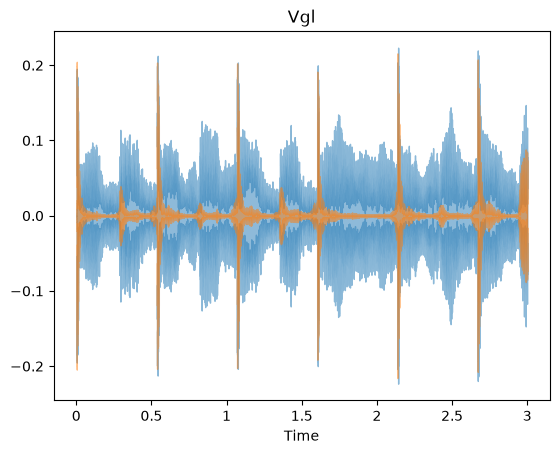

In [28]:
inversetrans = librosa.istft(stftrans, hop_length=hop_length)
print("Harmonics after inverse transform")
display(Audio(inversetrans, rate=sr))

fig, ax = plt.subplots(nrows=1, sharex=True)
librosa.display.waveshow(wav, sr=sr, alpha=0.5, ax=ax)
librosa.display.waveshow(percussive, sr=sr, alpha=0.5, ax=ax)
ax.set(title="Vgl")

## 4. Signalverarbeitung: Filterung und Rekonstruktion

Ein Vorteil der STFT ist ihre **Invertierbarkeit**: Wir können:
1. Das Spektrogram modifizieren (z.B. bestimmte Frequenzen entfernen)
2. Mit der inversen STFT wieder ein Audiosignal erzeugen

Dies ist die Grundlage für viele Audio-Verarbeitungstechniken wie:
- **Rauschreduzierung**: Schwache Frequenzen werden entfernt
- **Equalisierung**: Bestimmte Frequenzbereiche werden verstärkt/gedämpft
- **Effekte**: Zeitliche oder spektrale Modifikationen

In den folgenden Schritten werden wir das Chroma-Spektrogram filtern, um **aussagekräftige Noten** zu extrahieren.

In [30]:
# set weaker magnitudes to zero
def cut_off(myarray, threshold):
    cut_array = myarray.copy()
    indexes = cut_array < threshold
    cut_array[indexes] = 0
    return cut_array

# blur the chroma in x or time direction
def blur_note_length(chroma):
    # There is probably a much more elegant way to apply a filter with numpy
    blur_filter = np.array([0.15, 0.7, 0.15])
    blurred_chroma = np.zeros(chroma.shape) # shape is (12, 130). 12 pitches, 130 frames (or more/less depending on duration, window_length, etc.)
    start_blur_index = blur_filter.shape[0] // 2
# manually do first and last values: hard coded for blur.shape[0] = 3
    blurred_chroma[:,0] = chroma[:,0] * (blur_filter[0] + blur_filter[1]) # start
    blurred_chroma[:,1] = chroma[:,0] * (blur_filter[2])
    blurred_chroma[:,-1] = chroma[:,-1] * (blur_filter[0] + blur_filter[1]) # end
    blurred_chroma[:,-2] = chroma[:,-2] * (blur_filter[2])
    for index in range(start_blur_index, blurred_chroma.shape[1]-start_blur_index):
    # hard coded for blur.shape[0] = 3
        blurred_chroma[:,index-1] += chroma[:,index] * blur_filter[0]
        blurred_chroma[:,index]   += chroma[:,index] * blur_filter[1]
        blurred_chroma[:,index+1] += chroma[:,index] * blur_filter[2]
    return blurred_chroma

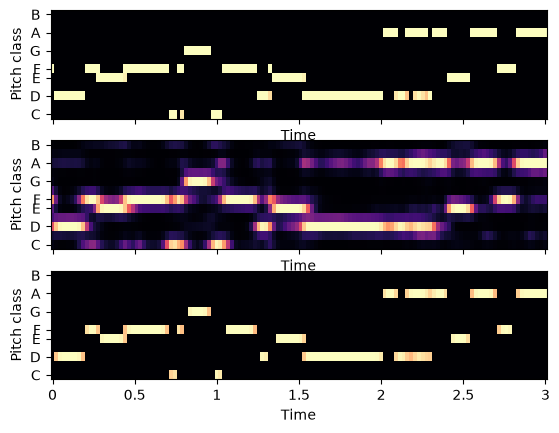

In [38]:
# clean_chroma = chroma.copy()
# cutoff = 0.85  # Magnitude
# indexes = clean_chroma < cutoff
# clean_chroma[indexes] = 0
clean_chroma = cut_off(chroma, 0.85)

# let's apply the blur twice for a stronger effect
blurred_chroma = blur_note_length(blur_note_length(chroma))

# show
fig, ax = plt.subplots(nrows=3, sharex=True)
ax[0].set(title='Clean chroma')
librosa.display.specshow(clean_chroma, y_axis='chroma', x_axis='time', ax=ax[0])
ax[1].set(title='Time blur')
librosa.display.specshow(blurred_chroma, y_axis='chroma', x_axis='time', ax=ax[1])
ax[2].set(title='Both together')
librosa.display.specshow(cut_off(blurred_chroma, 0.85), y_axis='chroma', x_axis='time', ax=ax[2])


### Filtertechniken: Cutoff und Blur

Zur Verbesserung der Noten-Extraktion werden zwei Filter angewandt:

1. **Cutoff-Filter**: Entfernt schwache Frequenzen
   - Nur Frequenzen mit ausreichend hoher Magnitude werden beibehalten
   - Reduziert Rauschen und Artefakte

2. **Blur-Filter**: Glättet das Spektrogram zeitlich
   - Glaubt Frequenzänderungen (Transients)
   - Vereinfacht die Erkennung von stabilen Tonhöhen
   - Mehrfaches Anwenden verstärkt den Effekt

Das Ergebnis ist ein **bereinigtes Chroma-Spektrogram**, das stabile Tonhöhenabschnitte deutlich macht.

In [40]:
# some tests with beat and tempo
tempo, beat_frames = librosa.beat.beat_track(y=longwav, sr=sr)
beat_times = librosa.frames_to_time(beat_frames, sr=sr)
beat_diff = beat_times[1:] - beat_times[:-1]
print(f"Beat diff analysis: Mean= {np.mean(beat_diff):.5f}, Std= {np.std(beat_diff):.5f}, 60/mean= {60/np.mean(beat_diff):.2f} bpm")
print(f"Tempo by librosas beat_track: {tempo} or {tempo[0]:.2f} beats per minute")

# the beat_track function detects a tempo of about 107 bpm
# the percussion track and onset curve however show 3 times as many peaks
# taking every third peak as beat results in 107 bpm
# taking every second peak however results in 161 bpm which is very close to the result we want

Beat diff analysis: Mean= 0.53406, Std= 0.00000, 60/mean= 112.35 bpm
Tempo by librosas beat_track: [112.34714674] or 112.35 beats per minute


c:\Users\Etherneteus\OneDrive - TH\OneDrive - Technische Hochschule Nürnberg Georg Simon Ohm\dev\ProjektarbeitMSY\autotranscribe\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=384 is too large for input signal of length=130
  warnings.warn(


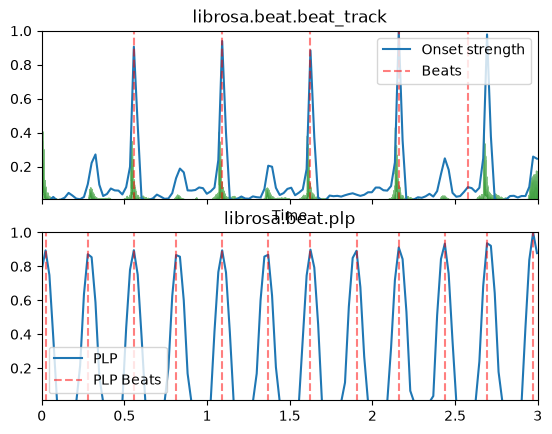

In [41]:
onset_env = librosa.onset.onset_strength(y=percussive, sr=sr)
pulse = librosa.beat.plp(onset_envelope=onset_env, sr=sr)


tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env)
beats_plp = np.flatnonzero(librosa.util.localmax(pulse))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True)
times = librosa.times_like(onset_env, sr=sr)
ax[0].plot(times, librosa.util.normalize(onset_env),
         label='Onset strength')
ax[0].vlines(times[beats], 0, 1, alpha=0.5, color='r',
           linestyle='--', label='Beats')
ax[0].legend()
ax[0].set(title='librosa.beat.beat_track')
ax[0].label_outer()
# ax[0].set(yscale='log') # makes peaks more uniformous

times = librosa.times_like(pulse, sr=sr)
ax[1].plot(times, librosa.util.normalize(pulse),
         label='PLP')
ax[1].vlines(times[beats_plp], 0, 1, alpha=0.5, color='r',
           linestyle='--', label='PLP Beats')
ax[1].legend()
ax[1].set(title='librosa.beat.plp', xlim=[0, 3], ylim=[0.01,1])
ax[1].xaxis.set_major_formatter(librosa.display.TimeFormatter())

librosa.display.waveshow(percussive*2, sr=sr, alpha=0.5, ax=ax[0], color='green')

## 5. Rhythmusanalyse: Beat und Tempo

Die **Erkennung von Beats und Tempo** ist essentiell für die Musikanalyse:

- **Tempo**: Die durchschnittliche Geschwindigkeit der Musik (in BPM - Beats Per Minute)
- **Beats**: Die rhythmischen Impulse, die die musikalische Zeit strukturieren

### Algorithmen zur Beat-Erkennung

**Beat Track** (Librosa Standard):
- Nutzt die Onset-Stärke (wo Noten/Perkussionsereignisse beginnen)
- Effizient, aber manchmal weniger präzise

**PLP (Probabilistic Latent Component Analysis)**:
- Probabilistischer Ansatz
- Kann mehrere Hypothesen verfolgen
- Oft präziser bei komplexem Rhythmus

Diese Analysen sind wichtig für die **Taktung und zeitliche Quantisierung** der erkannten Noten.

5.0 Should be 8.0


[Text(0.5, 1.0, 'Power spectrogram')]

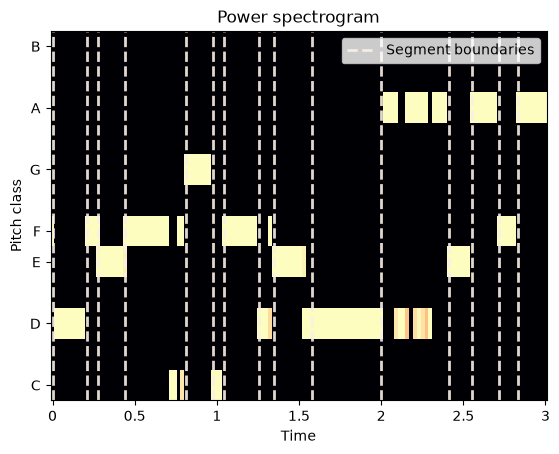

In [42]:
beats_in_sample = duration // np.mean(beat_diff)
bpm = 112.5 # from sheet music. 
spb = 60 / bpm
true_beats_in_sample = duration / spb
print(beats_in_sample, "Should be", true_beats_in_sample)

bounds = librosa.segment.agglomerative(chroma, int(true_beats_in_sample*2)-1) # chroma is much better than clean chroma for getting bounds

bound_times = librosa.frames_to_time(bounds, sr=sr)
offset = bound_times[3] # find a well aligned beat

rythm_times = np.linspace(0, duration, num=int(beats_in_sample*2), endpoint=False) + offset # add offset to align zero to beat
ryth_try = np.arange(0, duration, np.mean(beat_diff)/2) + offset

import matplotlib.transforms as mpt

fig, ax = plt.subplots()

trans = mpt.blended_transform_factory(

            ax.transData, ax.transAxes)

librosa.display.specshow(clean_chroma, y_axis='chroma', x_axis='time', ax=ax)

ax.vlines(bound_times, 0, 1, color='linen', linestyle='--',

          linewidth=2, alpha=0.9, label='Segment boundaries',

          transform=trans)

ax.legend()

ax.set(title='Power spectrogram')

In [43]:
# refresh imports
import librosa
import librosa.display
import numpy as np
import music21 as m21
import matplotlib.pyplot as plt

## 6. Praktische Anwendung: Automatische Transkription

Jetzt kombinieren wir alle bisherigen Konzepte zu einem **praktischen System für Musik-Transkription**:

1. **Pitch-Erkennung** mit Piptrack
   - Extrahiert die dominante Frequenz in jedem STFT-Fenster
   - Konvertiert zu MIDI-Noten-Nummern
   - Fmin/Fmax-Parameter begrenzen den Suchbereich

2. **Notendauern** aus Beat-Erkennung
   - Beats definieren die musikalischen Einheiten
   - Jeder Beat entspricht einer Note

3. **Music21 Integration**
   - Konvertiert extrahierte Noten zu MusicXML/Noten-Notation
   - Kann direkt in Musik-Notations-Software geöffnet werden

Die Herausforderung: **Zusammenfassung aufeinanderfolgender Frames gleicher Tonhöhe** zu einzelnen Noten.

In [44]:

def extract_notes(y, sr: int = 22050):
        
    # Harmonic-Percussive Separation
    y_harmonic, y_percussion = librosa.effects.hpss(y)

    # get tempo and beat times
    tempo, beats = librosa.beat.beat_track(y=y_percussion, sr=sr) # using y_percussion doesn't make a difference
    print(f"Tempo: {tempo} BPM")
    
    # get pitches through STFT
    # n_fft = 2048, win_length = n_fft, hop_length = win_lenght // 4 = 512
    # standard parameters are set to parabol windows of 2048 samples
    # which is about 93 ms at sr = 22050
    # one quarter note at tempo 160 lasts 60 / 160 = 0.375 seconds
    # TODO: test piptrack parameters threshold and ref
    # fewer bins?
    # longer windows, less overlapping
    # FFT Zero padding, interpoliert zwischen frequenzen -> kann Notenfrequenzen besser treffen, 
    # Window funktion ändern, parabol, hann, etc
    pitches, magnitudes = librosa.piptrack(y=y_harmonic, sr=sr, fmin=250, fmax=2000, n_fft=2048*4)#, threshold=1, ref=np.mean)
    print("Shape of pitches:", pitches.shape)
    # Mahr Treffen: Lukas: Do und Fr ganz

    notes = []
    durations = []
    
    if len(beats) > 1:
        beat_times = librosa.frames_to_time(beats, sr=sr)
        durations = np.diff(beat_times)
        durations = np.append(durations, durations[-1])  # repeat last duration for last note
    else:
        durations = [0.5] * pitches.shape[1]  # default duration if beats are not detected
    
    for t in range(pitches.shape[1]):
        index = np.argmax(magnitudes[:, t])# get index of loudest frequency
        pitch = pitches[index, t]           # get pitch of loudest frequency
        if pitch > 0:   # piptrack writes 0 as default
            note = librosa.hz_to_midi(pitch)# get midi number
            notes.append((round(note),1))
            # notes.append((round(note), durations[t]))       # round to next note and pass as tuple with duration
    
    # Problem: erzeugt eine Note für jedes STFT window. Besser: sehr große Windows?? oder: Noten zusammenfassen!

    return notes, tempo

def create_music21_score(notes, tempo):
    score = m21.stream.Stream()
    score.append(m21.tempo.MetronomeMark(number=tempo))
    
    for midi_note, duration in notes:
        note = m21.note.Note(midi_note)
        # note.duration = m21.duration.Duration(duration)
        note.duration = m21.duration.Duration(0.25)
        score.append(note)
    
    return score


In [ ]:
# bringing code down again from the top
# load a music file
duration = 3
audio_filename = audio_path
# wav, sr = librosa.load(audio_filename, offset=60, duration=duration) # sampling rate is the default 22050 here

notes, tempo = extract_notes(wav, sr)
tempo = int( (tempo[0] // 10) * 10 )
print(tempo, type(tempo))
print("Number of notes:", len(notes))
score = create_music21_score(notes, tempo)

# Save notation
out_filename = audio_filename[: audio_filename.find(".")] # cut off .wav from filename
score.write("musicxml", out_filename)

## 7. Zusammenfassung: Music Information Retrieval

Wir haben die **grundlegenden Techniken der automatischen Musikanalyse** kennengelernt:

### Zentrale Konzepte:
- **Signalverarbeitung**: HPSS, STFT, Filterung
- **Merkmal-Extraktion**: Spectrogramme, Chroma-Features, Pitch
- **Zeitliche Analysen**: Beat-Erkennung, Tempo-Estimation
- **Noten-Transkription**: Automatische Umwandlung in Musiknotation

### Praktische Anwendungen:
- 🎵 Automatische Transkription von Gesang und Instrumenten
- 🎼 Akkorderr­kennung und Harmonieanalyse
- 🎶 Musiksuche und -empfehlung
- ⏱️ Musik-Synchronisation und Alignment
- 🎹 Musikediting und Remixing

### Herausforderungen:
- Polyphonie (mehrere Noten gleichzeitig)
- Gesang und Sprache vs. Instrumente
- Qualität und Rauschunterdrückung
- Kulturelle Unterschiede (Stimmung, Tonsystem)

**Nächste Schritte:** Die Notizen in der letzten Zelle skizzieren Optimierungsideen für bessere Noten-Extraktion!

## Noten erzeugen
- Chroma erzeugen, ohne Bass, fmin= 256

### Menge der Noten
- Alle frames durchgehen
- Zähler pro Notenpitch
- Zähler erhöhen, falls lauter als threshold
## oder
- Zähler für Zeit
- Merker für Pitch vorher
- Wenn Pitch max magnitude gleich Pitch vorher
    - Zähler erhöhen um Zeit von frame - overlap
- Wenn Pitch verschieden
    - Wenn Zählerzeit größer gleich Achtelnote
        - +1 Note
    - Sonst
        - Verwerfen, Zähler 0

### Homogenität
Bezieht sich auf einen vorläufigen Notenabschnitt

- Mehrere Werte ausprobieren,
- besten Wert ermitteln
- Bester Wert:
    - hat bei möglichst wenigen Trennungen hohe Homogenität (gleich bleibende Note innerhalb des Abschnitts)
    - Länge der Trennungen sind annähernd Vielfache von Notenlängen

Oder:

Erste Beat Zeit finden,
Ab dort Frames zu Mindest-Notenlänge zusammenfassen
Dann gleiche Noten hintereinander kennzeichnen



Idee:
- mehrere Durchläufe mit unterschiedlicher Anzahl von Noten -> besten bewerten

### Beat Zeit:
Beat diffs grafisch zeigen
Histogramm dazu erstellen (wie viele von welcher Länge?)
Annahme, dass häufigste beat diff ein vielfaches von einer viertel Note ist?